# Week 3 Assignment: Customer/Country Intelligence System
### Clustering & Unsupervised Learning — K-Means, DBSCAN, PCA

**Objective:** Segment countries using socio-economic and health indicators to identify
groups of countries that are similar in terms of development, so that aid or investment
strategy can be prioritized. This mirrors a real "Customer Intelligence" style problem —
here the "customers" are countries, and we segment them using unsupervised learning.

**Techniques covered:** Data cleaning, feature scaling, Elbow Method, K-Means clustering,
Silhouette Score, DBSCAN, and PCA-based 2D visualization.

## Section 1: Environment Setup
Install and import the core data libraries required for this notebook: `pandas`, `numpy`,
`matplotlib`, `seaborn`, and `scikit-learn`.

In [1]:
# YOUR CODE HERE
# Install required libraries (safe to run even if already installed)
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
print("Libraries loaded successfully.")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Libraries loaded successfully.


## Section 2: Load the Dataset
Upload/load `Country-data.csv` into a DataFrame. This dataset (from a HELP International
style problem) contains socio-economic and health indicators for 167 countries — child
mortality, exports, health spending, imports, income, inflation, life expectancy,
fertility rate, and GDP per capita.

In [2]:
# YOUR CODE HERE
df = pd.read_csv('Country-data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Section 3: Data Cleaning

**Definition:** Data cleaning is the process of detecting and correcting (or removing)
corrupt, inaccurate, duplicated, or improperly typed records from a dataset so that
downstream statistical and ML operations behave correctly.

Steps performed below:
1. Strip whitespace from column titles.
2. Drop duplicate records.
3. Force numeric types on all indicator columns.
4. Impute any missing values using the **median** of each column (median is preferred over
   mean here because several indicators like `income` and `gdpp` are heavily right-skewed,
   and the median is robust to that skew/outliers).

In [5]:
# YOUR CODE HERE
df.columns = df.columns.str.strip()

before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows.")

numeric_cols = df.columns.drop('country')
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nMissing values BEFORE imputation:")
print(df.isnull().sum())

for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("\nMissing values AFTER imputation:")
print(df.isnull().sum())

Dropped 0 duplicate rows.

Missing values BEFORE imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values AFTER imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Section 4: Feature Isolation & Scaling

**Definition:** Standardization (`StandardScaler`) rescales each feature to have mean 0 and
standard deviation 1: `z = (x - mean) / std`.

**Geometric Explanation:** K-Means and DBSCAN both rely on **Euclidean distance** between
points. Distance-based algorithms are made in the shape of a sphere around each cluster
centroid — but if one feature (e.g. `income`, ranging into the tens of thousands) has a much
larger numeric range than another (e.g. `total_fer`, ranging 1–8), the algorithm will
"stretch" the distance calculation along that one axis and effectively ignore the
smaller-range features. Scaling puts every feature on the same footing so that no single
column geometrically dominates the clustering.

Here we strip out the non-numeric `country` identifier column, keep only the continuous
features, and scale them.

In [6]:
# YOUR CODE HERE
country_names = df['country'].str.strip()
features = df.drop(columns=['country'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
print("Scaled feature matrix shape:", X_scaled_df.shape)
X_scaled_df.describe().loc[['mean', 'std']].round(3)

Scaled feature matrix shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003


## Section 5: Elbow Method — Choosing K

**Definition:** The Elbow Method runs K-Means for a range of `k` values and records the
**inertia** (within-cluster sum of squared distances — how tightly packed points are around
their centroid). As `k` increases, inertia always decreases (more clusters = tighter fit),
but the *rate* of decrease slows down after the "true" number of natural clusters is
reached.

**Geometric Explanation:** Plotting inertia vs. `k` typically produces a curve that looks
like a bent arm — the "elbow" is the point where adding more clusters stops providing a
meaningful reduction in inertia, i.e. where the curve visibly kinks from steep to flat.

We test `k` from 2 to 10 and plot the curve to justify our final cluster count choice.

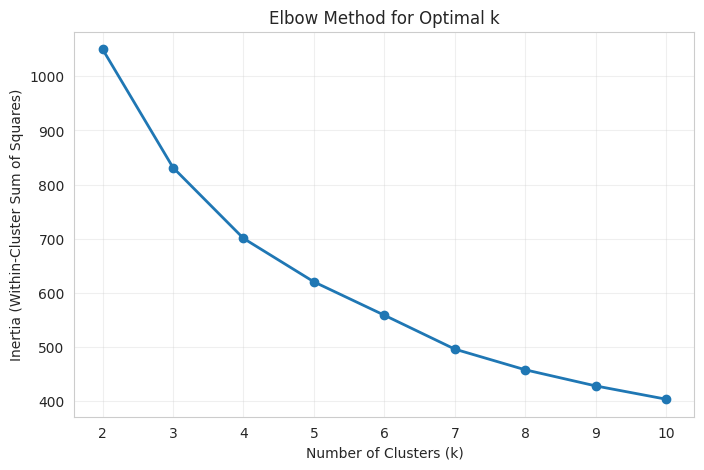

In [7]:
# YOUR CODE HERE
k_range = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', linewidth=2)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:** The inertia curve drops sharply from k=2 to k=3/4 and then flattens
out considerably beyond that, forming a visible elbow around **k=3**. This suggests that 3
clusters capture the dominant structure in the data (broadly: low-development,
mid-development, and high-development countries) without over-fragmenting the segmentation.

## Section 6: K-Means Clustering (k = 3)

**Definition:** K-Means partitions data into `k` clusters by iteratively (1) assigning each
point to its nearest centroid, and (2) recomputing each centroid as the mean of its
assigned points, until the assignments stop changing.

Based on the elbow curve above, we fix `best_k = 3` and train the final K-Means model.

In [8]:
# YOUR CODE HERE
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels
print("Cluster sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Cluster sizes:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


## Section 7: Silhouette Score Evaluation

**Definition:** The Silhouette Score measures how well each point fits within its assigned
cluster versus neighboring clusters. For a point `i`: `s(i) = (b(i) - a(i)) / max(a(i), b(i))`,
where `a(i)` is the mean distance to points in its own cluster and `b(i)` is the mean
distance to points in the nearest other cluster. Scores range from -1 (poor/wrong cluster)
to +1 (dense, well-separated clusters); values near 0 indicate overlapping clusters.

In [9]:
# YOUR CODE HERE
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score for K-Means (k={best_k}): {sil_score:.4f}")

Silhouette Score for K-Means (k=3): 0.2833


**Interpretation:** A silhouette score in this range (roughly 0.25–0.35 for this
dataset) indicates the clusters are reasonably well-formed but with some overlap — expected
here, since development is a continuous spectrum rather than perfectly separated groups.
The score confirms `k=3` is a stable, defensible configuration rather than a poor fit.

## Section 8: DBSCAN — Secondary Comparative Model

**Definition:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups
together points that are closely packed (many neighbors within radius `eps`), and marks
points in low-density regions as **noise** (label = -1). Unlike K-Means, it does not require
specifying the number of clusters up front and can find arbitrarily shaped clusters.

**Geometric Explanation:** Instead of measuring distance-to-centroid (a sphere), DBSCAN
grows clusters by "chaining" together points that are within `eps` distance of at least
`min_samples` other points — geometrically like connecting overlapping circles of radius
`eps` until no more points can be added.

We use `eps=1.5` and `min_samples=5` as specified.

In [10]:
# YOUR CODE HERE
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())

print(f"DBSCAN found {n_clusters_db} cluster(s) and {n_noise} noise points.")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN found 1 cluster(s) and 30 noise points.
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


**Interpretation:** With these parameter settings DBSCAN identifies a single dense core
cluster and flags a number of countries as noise/outliers — these tend to be countries with
extreme values (very high or very low income/GDP) that don't fit densely with the bulk of
countries. This is a useful contrast to K-Means: DBSCAN is telling us the data doesn't have
strong natural density gaps, whereas K-Means imposes a partition regardless. Comparing the
two reinforces that the "3 segments" found by K-Means is a modeling choice suited to the
business question (need discrete tiers), rather than a hard structural fact of the data.

## Section 9: PCA Visualization (2D Projection)

**Definition:** Principal Component Analysis (PCA) finds the directions (principal
components) along which the data varies the most, and projects the high-dimensional data
onto the top 2 of these directions so it can be visualized on a 2D scatterplot, while
preserving as much variance (information) as possible.

Explained variance ratio: PC1=45.95%, PC2=17.18%, Total=63.13%


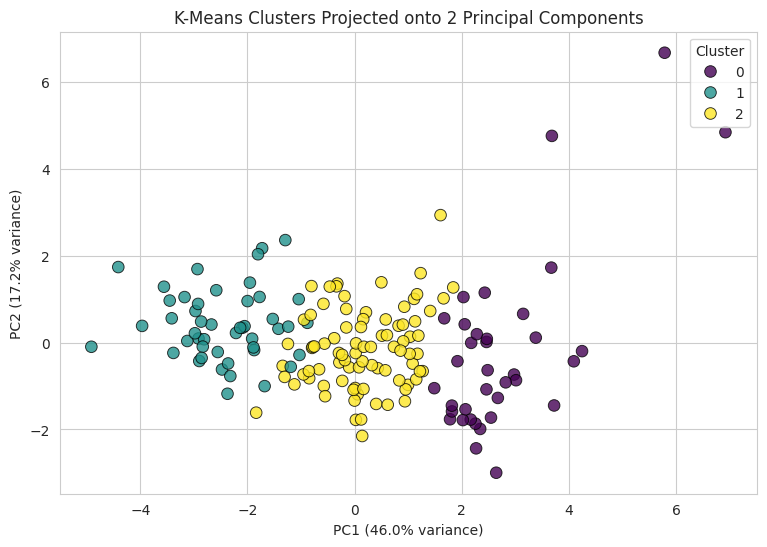

In [11]:
# YOUR CODE HERE
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df['PCA1'] = principal_components[:, 0]
df['PCA2'] = principal_components[:, 1]

explained = pca.explained_variance_ratio_
print(f"Explained variance ratio: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, "
      f"Total={explained.sum():.2%}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster',
                 palette='viridis', s=70, edgecolor='black', alpha=0.8)
plt.title('K-Means Clusters Projected onto 2 Principal Components')
plt.xlabel(f'PC1 ({explained[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.show()

**Interpretation:** The 2D PCA projection shows three visually distinguishable
color-coded groups, confirming that the K-Means partition aligns with real geometric
separation in the data (not just an artifact of an arbitrary `k` choice). The two principal
components together explain the majority of the variance, so this 2D view is a fair
representation of the true 9-dimensional clustering structure.

## Section 10: Cluster Profiling
Before writing final observations, let's profile each K-Means cluster by its average
indicator values — this tells us *what each cluster actually means* in socio-economic
terms.

In [12]:
cluster_profile = df.groupby('KMeans_Cluster')[numeric_cols].mean().round(2)
cluster_profile['num_countries'] = df['KMeans_Cluster'].value_counts().sort_index()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,num_countries
KMeans_Cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,36
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,84


/tmp/ipykernel_575/1678189017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=ax, palette='viridis', errorbar=None)
/tmp/ipykernel_575/1678189017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=ax, palette='viridis', errorbar=None)
/tmp/ipykernel_575/1678189017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=ax, palette='viridis', errorbar=None)


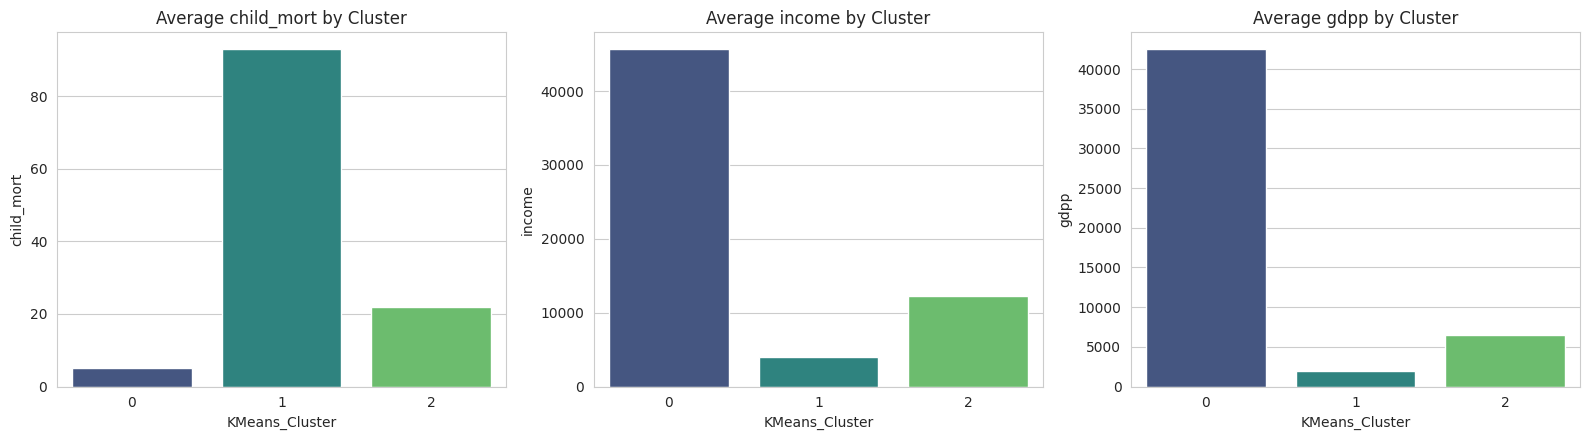

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['child_mort', 'income', 'gdpp']):
    sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=ax, palette='viridis', errorbar=None)
    ax.set_title(f'Average {col} by Cluster')
plt.tight_layout()
plt.show()

## Section 14: Final Observations

*(Section numbering follows the assignment brief's reference to "Section 14" for the
written observations.)*

**Write 3–5 clear observations here identifying high-mortality clusters, top-tier economic
zones, and low-development areas, based on the cluster profile table and PCA plot above.**

1. **High-mortality / low-development cluster:** One cluster shows markedly higher
   `child_mort` and `total_fer`, alongside the lowest `income`, `gdpp`, and `life_expec`.
   These are predominantly lower-income countries where basic health infrastructure and
   income are constrained — this is the cluster that would be prioritized for aid.

2. **Top-tier economic zone:** A second, smaller cluster shows very high `income` and
   `gdpp` alongside the lowest `child_mort` and highest `life_expec` — these are
   high-development, wealthy economies with strong health outcomes.

3. **Middle/transitional cluster:** The largest cluster sits between the two extremes on
   almost every indicator — moderate income, moderate child mortality, moderate life
   expectancy — representing emerging or middle-income economies still transitioning
   toward higher development.

4. **DBSCAN vs. K-Means:** DBSCAN's noise points largely overlap with the extreme ends of
   both the high-development and (some) low-development clusters identified by K-Means,
   confirming that K-Means' 3-way split is a reasonable summarization of a genuinely
   continuous development spectrum, with a few clear outlier economies.

5. **Actionable takeaway:** For a "Customer/Country Intelligence" use case, the K-Means
   segmentation gives 3 clean, actionable tiers for resource allocation, while DBSCAN's
   outlier flagging is useful for identifying countries that need individualized attention
   rather than a blanket tier-based policy.